In [274]:
# -*- coding: utf-8 -*-
"""HODLR.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/14KvYWxP0tBlyzeegHUdHDvBnIZciWb6V
"""

import numpy as np
from math import sqrt
from numpy.linalg import norm
from time import perf_counter
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---

# Reproducibility
np.random.seed(42)

## Global constants and toggles
##DEFAULT_USE_LOWRANK = True        # Set True for RandSVD/HODLR experiments
##DEFAULT_RANK_K = 20               # Target rank for low-rank approximations
##DEFAULT_POWER_ITERS = 1           # Power iterations for randomized SVD

CHEB_P = 8         #Chebyshev interpolation rank
MIN_BLOCK = 16     #Leaf size for HODLR recursion

# Choose Low-Rank Method (Change this in the experiment section)
# Options: 'ACA', 'RAND_SVD', 'HODLR'
#LOWRANK_METHOD = 'HODLR'


# --- 2. DATA GENERATION (Mixture of Gaussians) ---

rng = np.random.default_rng(42)
N = 100  # Reduced for quick testing

# Mixture on R_+ (positive axis): Two Gaussian components
x = np.abs(np.concatenate([
    rng.normal(loc=2.0, scale=0.4, size=N//2),
    rng.normal(loc=5.0, scale=0.7, size=N - N//2)
])).astype(float)
x.sort()

# Midpoints z_k between consecutive ordered samples; M = N-1
z = 0.5 * (x[:-1] + x[1:])
M = z.shape[0]

# Empirical CDF at midpoints: T_k = k/N, k = 1..N-1
T = np.arange(1, N) / N

# --- 3. GAUSSIAN KERNEL FUNCTIONS & MATRIX BUILDERS ---

SQRT2 = sqrt(2.0)
INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

In [275]:
def generate_mixture_gaussian_data(N, seed=42):
    """Generate mixture of Gaussians data (using existing logic)."""
    rng = np.random.default_rng(seed)
    x = np.abs(np.concatenate([
        rng.normal(loc=2.0, scale=0.4, size=N//2),
        rng.normal(loc=5.0, scale=0.7, size=N - N//2)
    ])).astype(float)
    x.sort()
    return x

def generate_exponential_data(N, seed=42):
    """Generate exponential distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.exponential(scale=2.0, size=N)
    x.sort()
    return x

def generate_uniform_data(N, seed=42):
    """Generate uniform distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(low=0.0, high=10.0, size=N)
    x.sort()
    return x

def generate_lognormal_data(N, seed=42):
    """Generate log-normal distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=1.0, sigma=0.5, size=N)
    x.sort()
    return x

def generate_beta_data(N, seed=42):
    """Generate beta distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.beta(a=2.0, b=5.0, size=N) * 10.0  # Scale to [0, 10]
    x.sort()
    return x

In [276]:
#normal pdf
def kappa(u):
    """Standard normal pdf φ(u). Vectorized."""
    return INV_SQRT_2PI * np.exp(-0.5 * u * u)

#normal cdf
def K(u):
    """Standard normal cdf Φ(u) via erf. Vectorized."""
    return 0.5 * (1.0 + erf(u / SQRT2))

In [277]:
def cheb_points(p):
    return np.cos((2*np.arange(p)+1)*np.pi/(2*p)) #return p chebyshev nodes in [-1,1] 

def scale11(x, a, b):
    return (2*x - (a+b)) / (b-a)  #maps any interval [a,b] to [-1,1] 

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))
    T[:,0] = 1.0
    if p > 1: T[:,1] = x
    for n in range(2, p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]
    return T

#computes U and V for one off diagonal block using baycentric lagrange
def cheb_UV(z_blk, x_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    Tt  = chebyshev_polynomials(t, p)
    W   = (2/p) * np.where(np.arange(p)==0, 0.5, 1.0)
    WTt = W[:,None] * Tt.T
    Tz  = chebyshev_polynomials(scale11(zb,az,bz), p)
    Tx  = chebyshev_polynomials(scale11(xb,ax,bx), p)
    U   = Tz @ WTt
    V   = Tx @ WTt
    return U, V

#Evaluates Gaussian CDF kernel only at pxp chebyshev node pairs, returns S only at pxp 
def cheb_S_K(z_blk, x_blk, h_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    zc = 0.5*(bz-az)*t + 0.5*(bz+az)
    xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
    return K((zc[:,None] - xc[None,:]) / h_blk.mean())

def cheb_S_D(z_blk, x_blk, h_blk, p):
    az, bz = z_blk.min(), z_blk.max()
    ax, bx = x_blk.min(), x_blk.max()
    if bz == az: bz += 1e-10
    if bx == ax: bx += 1e-10
    t = cheb_points(p)
    zc = 0.5*(bz-az)*t + 0.5*(bz+az)
    xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
    h_mean = h_blk.mean()
    diff = zc[:,None] - xc[None,:]
    return -kappa(diff/h_mean) * diff / (h_mean**2)




# CHEBYSHEV BASED HODLR IMPLEMENTATION (NO DENSE MATRIX)

#Always apply Chebyshev to off-diagonal blocks
def is_admissible(z_blk, x_blk):
    #For Gaussian CDF kernel, off-diagonal blocks are low-rank due to smoothness of the kernel, not spatial separation.
    #Singular values decay to 1e-16 at p=8 even for adjacent blocks. So always apply Chebyshev to off-diagonal blocks.
    return True   

def hodlr_build_UV(z, x, p=8, min_block=16):
    #Build UV structure once. No kernel evaluations here.
    def build(zi, xi):
        z_blk = z[zi]; x_blk = x[xi]
        if len(zi) <= min_block or len(xi) <= min_block:
            return {'type': 'dense', 'zi': zi, 'xi': xi}

        zm = len(zi)//2; xm = len(xi)//2
        zi1, zi2 = zi[:zm], zi[zm:]
        xi1, xi2 = xi[:xm], xi[xm:]

        def make_off(zii, xii):
            zb = z[zii]; xb = x[xii]
            az, bz = zb.min(), zb.max()
            ax, bx = xb.min(), xb.max()
            if bz == az: bz += 1e-10
            if bx == ax: bx += 1e-10
            t = cheb_points(p)
            Tt  = chebyshev_polynomials(t, p)
            W   = (2/p) * np.where(np.arange(p)==0, 0.5, 1.0)
            WTt = W[:,None] * Tt.T
            Tz  = chebyshev_polynomials(scale11(zb,az,bz), p)
            Tx  = chebyshev_polynomials(scale11(xb,ax,bx), p)
            U   = Tz @ WTt
            V   = Tx @ WTt
            zc = 0.5*(bz-az)*t + 0.5*(bz+az)  # physical Cheb nodes
            xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
            return {'type': 'lowrank', 'U': U, 'V': V,
                    'zc': zc, 'xc': xc, 'xi': xii}

        return {'type': 'node',
                'H11': build(zi1, xi1), 'H22': build(zi2, xi2),
                'off12': make_off(zi1, xi2), 'off21': make_off(zi2, xi1),
                'zi': zi, 'xi': xi, 'zm': zm}

    return build(np.arange(len(z)), np.arange(len(x)))


def hodlr_fill_S_K(node, z, x, h):
    #Fill S for KDE forward pass, called each iteration. This calls only pxp S matrices, as U and V are already fixed  
    if node['type'] == 'dense':
        zi, xi = node['zi'], node['xi']
        node['K'] = K((z[zi][:,None] - x[xi][None,:]) / h[xi][None,:])
        return
    hodlr_fill_S_K(node['H11'], z, x, h)
    hodlr_fill_S_K(node['H22'], z, x, h)
    for off in [node['off12'], node['off21']]:
        h_mean = h[off['xi']].mean()
        off['S'] = K((off['zc'][:,None] - off['xc'][None,:]) / h_mean)


def hodlr_fill_S_D(node, z, x, h):
    #Fill S for gradient pass, called each iteration. This calls only pxp S matrices, as U and V are already fixed
    if node['type'] == 'dense':
        zi, xi = node['zi'], node['xi']
        diff = z[zi][:,None] - x[xi][None,:]
        hloc = h[xi][None,:]
        node['K'] = -kappa(diff/hloc) * diff / (hloc**2)
        return
    hodlr_fill_S_D(node['H11'], z, x, h)
    hodlr_fill_S_D(node['H22'], z, x, h)
    for off in [node['off12'], node['off21']]:
        h_mean = h[off['xi']].mean()
        diff = off['zc'][:,None] - off['xc'][None,:]
        off['S'] = -kappa(diff/h_mean) * diff / (h_mean**2)

# Matrix-vector product
#Computes kxv without forming K, each off diagonal does U@(S@(V^t @ v)), three small matrix vector products instead of one large one.
def hodlr_matvec(node, v):

    if node['type'] == 'dense':
        return node['K'] @ v[node['xi']]

    zm = node['zm']
    out = np.zeros(len(node['zi']))

    # Diagonal
    out[:zm]  += hodlr_matvec(node['H11'], v)
    out[zm:]  += hodlr_matvec(node['H22'], v)

    # Off-diagonal 12
    off12 = node['off12']
    if off12['type'] == 'lowrank':
        out[:zm] += off12['U'] @ (off12['S'] @ (off12['V'].T @ v[off12['xi']]))
    else:
        out[:zm] += off12['K'] @ v[off12['xi']]

    # Off-diagonal 21
    off21 = node['off21']
    if off21['type'] == 'lowrank':
        out[zm:] += off21['U'] @ (off21['S'] @ (off21['V'].T @ v[off21['xi']]))
    else:
        out[zm:] += off21['K'] @ v[off21['xi']]

    return out



# Transpose matrix-vector product
#computes K^t @ r
def hodlr_rmatvec(node, r):

    N_total = node['xi'][-1] + 1

    def recurse(nd, r_sub):
        if nd['type'] == 'dense':
            g = np.zeros(N_total)
            g[nd['xi']] += nd['K'].T @ r_sub
            return g

        zm = nd['zm']
        r1, r2 = r_sub[:zm], r_sub[zm:]
        g = np.zeros(N_total)

        g += recurse(nd['H11'], r1)
        g += recurse(nd['H22'], r2)

        off12 = nd['off12']
        if off12['type'] == 'lowrank':
            g[off12['xi']] += off12['V'] @ (off12['S'].T @ (off12['U'].T @ r1))
        else:
            g[off12['xi']] += off12['K'].T @ r1

        off21 = nd['off21']
        if off21['type'] == 'lowrank':
            g[off21['xi']] += off21['V'] @ (off21['S'].T @ (off21['U'].T @ r2))
        else:
            g[off21['xi']] += off21['K'].T @ r2

        return g

    return recurse(node, r)

In [278]:
def solve_kde_enhanced(x, z, T, *,
                       method='DENSE',
                       p=8,
                       min_block=16,
                       eta=0.5,
                       max_iters=400,
                       tol=1e-8,
                       verbose=False):

    N = len(x)
    M = len(z)

    time_build = 0.0
    time_ops   = 0.0

    J_hist = []
    t_hist = []
    grad_norm_hist = []

    t0_total = perf_counter()
    
    # Build UV structure once for CHEB_HODLR 
    if method == 'CHEB_HODLR':
        t0 = perf_counter()
        tree = hodlr_build_UV(z, x, p=p, min_block=min_block)
        time_build += perf_counter() - t0


    # Forward KDE evaluation
    def _F_hat(h):
        nonlocal time_build, time_ops

        if method == 'DENSE':
            t0 = perf_counter()
            U_arg = (z[:, None] - x[None, :]) / h[None, :]
            y = K(U_arg) @ np.ones(N) / N
            time_ops += perf_counter() - t0
            return y

        elif method == 'CHEB_HODLR':
            t0 = perf_counter()
            hodlr_fill_S_K(tree, z, x, h)   # only recomputes p×p S matrices
            time_build += perf_counter() - t0
            t1 = perf_counter()
            y = hodlr_matvec(tree, np.ones(N)) / N
            time_ops += perf_counter() - t1
            return y

    # Gradient — returns (gradient, J_curr) to avoid extra fill
    def _grad_J(h):
        nonlocal time_build, time_ops

        r = _F_hat(h) - T
        J_curr = float(r @ r)

        if method == 'DENSE':
            diff = z[:, None] - x[None, :]
            U_arg = diff / h[None, :]
            D = -kappa(U_arg) * diff / (h[None, :]**2)
            g = (2.0 / N) * (D.T @ r)

        elif method == 'CHEB_HODLR':
            t0 = perf_counter()
            hodlr_fill_S_D(tree, z, x, h)   # reuse same tree structure
            time_build += perf_counter() - t0
            t1 = perf_counter()
            g = (2.0 / N) * hodlr_rmatvec(tree, r)
            time_ops += perf_counter() - t1

        return g, J_curr

    # _J only used for backtracking line search
    def _J(a):
        h_local = np.exp(a)
        r_local = _F_hat(h_local) - T
        return float(r_local @ r_local)

    # Initialization
    data_span = x.max() - x.min()
    h0 = max(0.2 * data_span / (N**0.2), 1e-3)
    h = np.full(N, h0)
    alpha = np.log(h)

    J0 = _J(alpha)
    J_hist.append(J0)
    t_hist.append(0.0)
    grad_norm_hist.append(0.0)

    if verbose:
        print(f"[{method}] Initial J = {J0:.6f}")
        
    # Gradient descent
    for k in range(max_iters):

        h = np.exp(alpha)

        grad_h, J_curr = _grad_J(h)
        grad_alpha = grad_h * h
        grad_norm  = norm(grad_alpha)

        alpha_new = alpha - eta * grad_alpha
        alpha_new = np.clip(alpha_new,
                            np.log(1e-3),
                            np.log(5.0 * data_span))

        J_new = _J(alpha_new)

        # Backtracking
        tries = 0
        while J_new > J_curr and tries < 10:
            eta *= 0.5
            alpha_new = alpha - eta * grad_alpha
            alpha_new = np.clip(alpha_new,
                                np.log(1e-3),
                                np.log(5.0 * data_span))
            J_new = _J(alpha_new)
            tries += 1

        alpha = alpha_new

        J_hist.append(J_new)
        t_hist.append(perf_counter() - t0_total)
        grad_norm_hist.append(grad_norm)

        if verbose and (k+1) % 20 == 0:
            print(f"iter {k+1:3d}: J={J_new:.6f}, ||grad||={grad_norm:.2e}")

        if grad_norm < tol:
            if verbose:
                print(f"Converged at iteration {k+1}")
            break

    h_opt = np.exp(alpha)

    metrics = {
        "method": method,
        "p": p,
        "min_block": min_block,
        "J_final": J_hist[-1],
        "J_initial": J_hist[0],
        "total_time": t_hist[-1],
        "time_build": time_build,
        "time_ops": time_ops,
        "iterations": len(J_hist) - 1,
        "final_grad_norm": grad_norm_hist[-1],
        "J_hist": J_hist,
        "t_hist": t_hist,
        "grad_norm_hist": grad_norm_hist,
        "h_stats": (
            float(h_opt.min()),
            float(np.median(h_opt)),
            float(h_opt.max())
        )
    }

    return h_opt, metrics

In [279]:
def true_mixture(u, SQRT2):
    """True mixture density from which data was drawn."""
    INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

    def component_pdf(u, loc, scale):
        u_scaled = (u - loc) / scale
        return (1/scale) * INV_SQRT_2PI * np.exp(-0.5 * u_scaled**2)

    f1 = component_pdf(u, loc=2.0, scale=0.4)
    f2 = component_pdf(u, loc=5.0, scale=0.7)

    result = 0.5 * f1 + 0.5 * f2
    result[u < 0] = 0
    return result

def kde_estimate(u, x, h):
    """Evaluate KDE at points u using sample points x and per-sample bandwidths h."""
    U = (u[:, None] - x[None, :]) / h[None, :]
    return np.mean(kappa(U) / h[None, :], axis=1)

def kde_true_error(u, x, h, SQRT2):
    """
    Compute L2 error between true mixture density and KDE estimate.
    """

    # true density
    f_true = true_mixture(u, SQRT2)

    # KDE estimate
    f_kde = kde_estimate(u, x, h)

    # L2 error
    error = np.sqrt(np.mean((f_true - f_kde)**2))

    return error


In [280]:
def run_scaling_experiment(N_values=[500, 1000, 2000, 3000],
                          ranks=[10, 15, 20],
                          min_blocks=[16, 32],
                          distributions=['mixture_gaussian', 'exponential', 'uniform']):
    """
    Run comprehensive scaling experiments across different problem sizes,
    Chebyshev orders (p), and distributions.
    """

    data_generators = {
        'mixture_gaussian': generate_mixture_gaussian_data,
        'exponential': generate_exponential_data,
        'uniform': generate_uniform_data,
        'lognormal': generate_lognormal_data,
        'beta': generate_beta_data
    }

    results = {}

    print("COMPREHENSIVE CHEBYSHEV-HODLR vs DENSE ANALYSIS")
  

    for dist_name in distributions:
        print(f"\nAnalyzing {dist_name.upper()} Distribution")
        results[dist_name] = {'dense': [], 'hodlr': {}}

        generate_data = data_generators[dist_name]

        for N in N_values:
            print(f"  N = {N}")

            # Generate data
            x = generate_data(N)
            z = 0.5 * (x[:-1] + x[1:])
            T = np.arange(1, N) / N

            
            # Dense baseline 
          
            print("Running Dense baseline...")
            
        
            h_dense, m_dense = solve_kde_enhanced(
                x, z, T,
                method='DENSE',
                max_iters=100,   # <-- add this
                tol=1e-6,        # <-- add this
                verbose=False
            )
            results[dist_name]['dense'].append(m_dense)

       
            # Chebyshev-HODLR experiments
        
            for rank in ranks:
                for min_block in min_blocks:
                    key = f'p{rank}_b{min_block}'
                    if key not in results[dist_name]['hodlr']:
                        results[dist_name]['hodlr'][key] = []

                    print(f"    Running CHEB_HODLR (p={rank}, min_block={min_block})...")

                    h_hodlr, m_hodlr = solve_kde_enhanced(
                        x, z, T,
                        method='CHEB_HODLR',
                        p=rank,
                        min_block=min_block,
                        max_iters=100,  
                        tol=1e-6,       
                        verbose=False
                    )

                    results[dist_name]['hodlr'][key].append(m_hodlr)

    return results, N_values

In [281]:
def create_comprehensive_plots(results, N_values, save_plots=True):
    """
    Create all the requested plots from the analysis results.
    """

    distributions = list(results.keys())
    n_dists = len(distributions)

    # Create a large figure with subplots
    fig = plt.figure(figsize=(20, 5*n_dists))

    for idx, dist_name in enumerate(distributions):
        dist_results = results[dist_name]

        # 1. Time vs N for both methods
        plt.subplot(n_dists, 4, idx*4 + 1)

        # Dense times
        dense_times = [m['total_time'] for m in dist_results['dense']]
        plt.loglog(N_values, dense_times, 'ko-', linewidth=3, markersize=8, label='Dense (Full GD)')

        # HODLR times
        for key, cheb_list in dist_results['hodlr'].items():
            hodlr_times = [m['total_time'] for m in cheb_list]
            plt.loglog(N_values, hodlr_times, 'o-', linewidth=2, markersize=6, label=f'CHEB_HODLR {key}')

        plt.xlabel('Problem Size N')
        plt.ylabel('Total Time (seconds)')
        plt.title(f'Time vs N - {dist_name.title()}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 2. CHEB_HODLR Build vs MatVec
        plt.subplot(n_dists, 4, idx*4 + 2)

        for key, cheb_list in dist_results['hodlr'].items():
            construction_times = [m['time_build'] for m in cheb_list]
            gradient_times = [m['time_ops'] for m in cheb_list]

            plt.loglog(N_values, construction_times, 's-', linewidth=2, markersize=6,
                      label=f'CHEB_HODLR Constr. {key}')
            plt.loglog(N_values, gradient_times, 'o-', linewidth=2, markersize=6,
                      alpha=0.7, label=f'Grad. Desc. {key}')

        plt.xlabel('Problem Size N')
        plt.ylabel('Time (seconds)')
        plt.title(f'CHEB_HODLR Build vs MatVec - {dist_name.title()}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 3. Error vs N
        plt.subplot(n_dists, 4, idx*4 + 3)

        for key, cheb_list in dist_results['hodlr'].items():
            errors = [abs(cheb_list[i]['J_final'] - dist_results['dense'][i]['J_final']) /
                     dist_results['dense'][i]['J_final'] for i in range(len(N_values))]
            plt.loglog(N_values, errors, 'o-', linewidth=2, markersize=6, label=f'CHEB_HODLR {key}')

        plt.xlabel('Problem Size N')
        plt.ylabel('Relative Error')
        plt.title(f'Error vs N - {dist_name.title()}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 4. Loss vs Iteration (for largest N)
        plt.subplot(n_dists, 4, idx*4 + 4)

        largest_idx = -1  # Last (largest) N
        dense_J_hist = dist_results['dense'][largest_idx]['J_hist']
        plt.semilogy(range(len(dense_J_hist)), dense_J_hist, 'k-', linewidth=3, label='Dense')

        for key, cheb_list in dist_results['hodlr'].items():
            hodlr_J_hist = cheb_list[largest_idx]['J_hist']
            plt.semilogy(range(len(hodlr_J_hist)), hodlr_J_hist, '-', linewidth=2, label=f'CHEB_HODLR {key}')

        plt.xlabel('Iteration')
        plt.ylabel('Objective Function J')
        plt.title(f'Loss vs Iteration (N={N_values[largest_idx]}) - {dist_name.title()}')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_plots:
        plt.savefig('hodlr_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
        print("Plot saved as 'hodlr_comprehensive_analysis.png'")

    plt.show()

def create_loss_vs_iteration_plot(results, N_values, distribution='mixture_gaussian', save_plot=True):
    """
    Create detailed loss vs iteration plots for different methods and ranks.
    """

    dist_results = results[distribution]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot for each N value
    for i, N in enumerate(N_values):
        ax = axes[i//2, i%2] if len(N_values) > 1 else axes[0, 0]

        # Dense baseline
        dense_result = dist_results['dense'][i]
        ax.semilogy(range(len(dense_result['J_hist'])), dense_result['J_hist'],
                   'k-', linewidth=3, label='Dense', marker='o', markersize=4)

        # HODLR results
        for key, cheb_list in dist_results['hodlr'].items():
            cheb_result = cheb_list[i]
            ax.semilogy(range(len(cheb_result['J_hist'])), cheb_result['J_hist'],
                       '-', linewidth=2, label=f'CHEB_HODLR {key}', marker='s', markersize=3)

        ax.set_xlabel('Iteration')
        ax.set_ylabel('Objective Function J (Loss)')
        ax.set_title(f'Loss vs Iteration (N={N}) - {distribution.title()}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for i in range(len(N_values), 4):
        axes[i//2, i%2].set_visible(False)

    plt.tight_layout()

    if save_plot:
        plt.savefig('loss_vs_iteration_analysis.png', dpi=300, bbox_inches='tight')
        print("Loss vs iteration plot saved as 'loss_vs_iteration_analysis.png'")

    plt.show()

def create_gradient_descent_time_plot(results, N_values, save_plot=True):
    """
    Create plot showing ONLY gradient descent time (excluding HODLR construction) vs N.
    """

    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
    if len(results) == 1:
        axes = [axes]

    for idx, (dist_name, dist_results) in enumerate(results.items()):
        ax = axes[idx]

        # Dense gradient descent times (which is total time for dense)
        dense_gd_times = [m['total_time'] for m in dist_results['dense']]
        ax.loglog(N_values, dense_gd_times, 'ko-', linewidth=3, markersize=8,
                 label='Dense (Pure GD)')

        # HODLR gradient descent times (excluding construction)
        for key, cheb_list in dist_results['hodlr'].items():
            hodlr_gd_times = [m['time_ops'] for m in cheb_list]
            ax.loglog(N_values, hodlr_gd_times, 'o-', linewidth=2, markersize=6,
                     label=f'CHEB_HODLR {key} (Pure GD)')

        ax.set_xlabel('Problem Size N')
        ax.set_ylabel('Pure Gradient Descent Time (seconds)')
        ax.set_title(f'Pure Gradient Descent Time vs N\n{dist_name.title()}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_plot:
        plt.savefig('pure_gradient_descent_time.png', dpi=300, bbox_inches='tight')
        print("Pure gradient descent time plot saved as 'pure_gradient_descent_time.png'")

    plt.show()

def create_final_distributions_plot(results, N_values, distribution='mixture_gaussian', save_plot=True):
    """
    Create plots showing the final KDE distributions for different ranks.
    """

    # Use the largest N for comparison
    largest_N_idx = -1
    N = N_values[largest_N_idx]

    # Generate test data for the same distribution
    data_generators = {
        'mixture_gaussian': generate_mixture_gaussian_data,
        'exponential': generate_exponential_data,
        'uniform': generate_uniform_data,
        'lognormal': generate_lognormal_data,
        'beta': generate_beta_data
    }

    x_test = data_generators[distribution](N)
    u_plot = np.linspace(x_test.min(), x_test.max() + 1, 500)

    dist_results = results[distribution]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Left plot: Dense vs HODLR distributions
    ax1 = axes[0]

    # Get optimal bandwidths from results
    dense_result = dist_results['dense'][largest_N_idx]
    h_dense_avg = dense_result['h_stats'][1]  # median
    h_dense = np.full_like(x_test, h_dense_avg)

    f_kde_dense = kde_estimate(u_plot, x_test, h_dense)
    ax1.plot(u_plot, f_kde_dense, 'k-', linewidth=3, label='Dense')

    for key, cheb_list in dist_results['hodlr'].items():
        cheb_result = cheb_list[largest_N_idx]
        h_hodlr_avg = cheb_result['h_stats'][1]  # median
        h_hodlr = np.full_like(x_test, h_hodlr_avg)

        f_kde_hodlr = kde_estimate(u_plot, x_test, h_hodlr)
        ax1.plot(u_plot, f_kde_hodlr, '--', linewidth=2, label=f'CHEB_HODLR {key}')

    ax1.hist(x_test, bins=30, density=True, alpha=0.3, color='gray', label='Data histogram')
    ax1.set_xlabel('x')
    ax1.set_ylabel('Density')
    ax1.set_title(f'Final KDE Distributions (N={N})\n{distribution.title()}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Right plot: Error analysis across ranks
    ax2 = axes[1]

    ranks = sorted(list(set([int(key.split('_')[0].replace('p','')) for key in dist_results['hodlr'].keys()])))

    for N_idx, N_val in enumerate(N_values):
        errors = []
        rank_list = []

        for rank in ranks:
            matching_keys = [key for key in dist_results['hodlr'].keys() if key.startswith(f'p{rank}_')]
            if matching_keys:
                key = matching_keys[0]
                dense_J = dist_results['dense'][N_idx]['J_final']
                hodlr_J = dist_results['hodlr'][key][N_idx]['J_final']
                errors.append(abs(hodlr_J - dense_J) / dense_J)
                rank_list.append(rank)

        ax2.semilogy(rank_list, errors, 'o-', linewidth=2, markersize=6, label=f'N={N_val}')

    ax2.set_xlabel('Rank')
    ax2.set_ylabel('Relative Error in Final Loss')
    ax2.set_title('Distribution Accuracy vs Rank')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_plot:
        plt.savefig('final_distributions_analysis.png', dpi=300, bbox_inches='tight')
        print("Final distributions plot saved as 'final_distributions_analysis.png'")

    plt.show()

def create_rank_analysis_plot(results, N_values, distribution='mixture_gaussian'):
    """
    Create detailed analysis of how different ranks affect accuracy and performance.
    """

    dist_results = results[distribution]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Extract rank information
    ranks = sorted(list(set([int(key.split('_')[0].replace('p','')) for key in dist_results['hodlr'].keys()])))

    # 1. Speedup vs Rank
    axes[0, 0].set_title('Speedup vs Rank')
    for N_idx, N in enumerate(N_values):
        speedups = []
        rank_list = []
        for rank in ranks:
            # Find results for this rank (use first block size available)
            matching_keys = [key for key in dist_results['hodlr'].keys() if key.startswith(f'p{rank}_')]
            if matching_keys:
                key = matching_keys[0]
                dense_time = dist_results['dense'][N_idx]['total_time']
                hodlr_time = dist_results['hodlr'][key][N_idx]['total_time']
                speedups.append(dense_time / hodlr_time)
                rank_list.append(rank)

        axes[0, 0].plot(rank_list, speedups, 'o-', label=f'N={N}')

    axes[0, 0].set_xlabel('Rank')
    axes[0, 0].set_ylabel('Speedup Factor')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Error vs Rank
    axes[0, 1].set_title('Error vs Rank')
    for N_idx, N in enumerate(N_values):
        errors = []
        rank_list = []
        for rank in ranks:
            matching_keys = [key for key in dist_results['hodlr'].keys() if key.startswith(f'p{rank}_')]
            if matching_keys:
                key = matching_keys[0]
                dense_J = dist_results['dense'][N_idx]['J_final']
                hodlr_J = dist_results['hodlr'][key][N_idx]['J_final']
                errors.append(abs(hodlr_J - dense_J) / dense_J)
                rank_list.append(rank)

        axes[0, 1].semilogy(rank_list, errors, 'o-', label=f'N={N}')

    axes[0, 1].set_xlabel('Rank')
    axes[0, 1].set_ylabel('Relative Error')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Construction Time Ratio vs Rank
    axes[1, 0].set_title('CHEB_HODLR Construction Time Ratio vs Rank')
    for N_idx, N in enumerate(N_values):
        ratios = []
        rank_list = []
        for rank in ranks:
            matching_keys = [key for key in dist_results['hodlr'].keys() if key.startswith(f'p{rank}_')]
            if matching_keys:
                key = matching_keys[0]
                construction_time = dist_results['hodlr'][key][N_idx]['time_build']
                total_time = dist_results['hodlr'][key][N_idx]['total_time']
                ratios.append(construction_time / total_time if total_time > 0 else 0)
                rank_list.append(rank)

        axes[1, 0].plot(rank_list, ratios, 'o-', label=f'N={N}')

    axes[1, 0].set_xlabel('Rank')
    axes[1, 0].set_ylabel('Construction Time / Total Time')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Memory Complexity Estimate (based on rank)
    axes[1, 1].set_title('Estimated Memory Usage vs Rank')
    for rank in ranks:
        memory_estimates = []
        for N in N_values:
            dense_memory = N * N
            hodlr_memory = N * rank * 4  # Factor of 4 for multiple matrices
            memory_estimates.append(hodlr_memory / dense_memory)

        axes[1, 1].semilogy(N_values, memory_estimates, 'o-', label=f'Rank {rank}')

    axes[1, 1].set_xlabel('Problem Size N')
    axes[1, 1].set_ylabel('CHEB_HODLR Memory / Dense Memory')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('hodlr_rank_analysis.png', dpi=300, bbox_inches='tight')
    print("Rank analysis plot saved as 'hodlr_rank_analysis.png'")
    plt.show()

def print_timing_breakdown(results, N_values):
    """
    Print detailed timing breakdown showing CHEB_HODLR Build vs MatVec times.
    """

 
    print("DETAILED TIMING BREAKDOWN: CHEB_HODLR Build vs MatVec")
  

    for dist_name, dist_results in results.items():
        print(f"\n{dist_name.upper()} Distribution:")
 

        print(f"{'N':<8} {'Method':<15} {'Total':<8} {'CHEB_HODLR_Constr':<12} {'Grad_Desc':<10} {'Constr_Ratio':<12} {'Speedup':<8}")

        for i, N in enumerate(N_values):
            dense_result = dist_results['dense'][i]

            # Dense row
            print(f"{N:<8} {'Dense':<15} {dense_result['total_time']:<8.3f} {'-':<12} {dense_result['total_time']:<10.3f} {'-':<12} {'1.00x':<8}")

            # HODLR results
            for key, cheb_list in dist_results['hodlr'].items():
                cheb_result = cheb_list[i]
                speedup = dense_result['total_time'] / cheb_result['total_time']
                constr_ratio = cheb_result['time_build'] / cheb_result['total_time'] if cheb_result['total_time'] > 0 else 0

                print(f"{N:<8} {f'CHEB_HODLR_{key}':<15} {cheb_result['total_time']:<8.3f} "
                      f"{cheb_result['time_build']:<12.3f} "
                      f"{cheb_result['time_ops']:<10.3f} "
                      f"{constr_ratio:<12.3f} {f'{speedup:.2f}x':<8}")



In [282]:
def run_complete_analysis():
    """
    Run the complete CHEB_HODLR analysis pipeline
    """

    # Define experiment parameters
    N_values = [500, 1000, 2000, 4000]
    ranks = [10, 15, 20]
    min_blocks = [16, 32]
    distributions = ['mixture_gaussian', 'exponential', 'uniform']

    print("Starting comprehensive CHEB_HODLR analysis...")
    print("This will take several minutes to complete.")

    # Run scaling experiments
    results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)

    # Create comprehensive plots
    create_comprehensive_plots(results, N_values)

    # Create loss vs iteration plots
    for dist in distributions:
        create_loss_vs_iteration_plot(results, N_values, dist)

    # Create pure gradient descent time plot
    create_gradient_descent_time_plot(results, N_values)

    # Create final distributions comparison
    for dist in distributions:
        create_final_distributions_plot(results, N_values, dist)

    # Create rank analysis plot for mixture_gaussian
    create_rank_analysis_plot(results, N_values, 'mixture_gaussian')

    # Print timing breakdown
    print_timing_breakdown(results, N_values)

    # Summary statistics

    print("SUMMARY STATISTICS")
 

    for dist_name, dist_results in results.items():
        print(f"\n{dist_name.upper()} Distribution Summary:")

        # Average speedups across all configurations
        speedups = []
        errors = []

        for key, cheb_list in dist_results['hodlr'].items():
            for i, cheb_result in enumerate(cheb_list):
                dense_result = dist_results['dense'][i]
                speedup = dense_result['total_time'] / cheb_result['total_time']
                error = abs(cheb_result['J_final'] - dense_result['J_final']) / dense_result['J_final']
                speedups.append(speedup)
                errors.append(error)

        print(f"  Average speedup: {np.mean(speedups):.2f}x (std: {np.std(speedups):.2f})")
        print(f"  Average relative error: {np.mean(errors):.2e} (std: {np.std(errors):.2e})")
        print(f"  Max speedup achieved: {np.max(speedups):.2f}x")
        print(f"  Min error achieved: {np.min(errors):.2e}")

    return results, N_values

In [283]:
def run_quick_demo():
    """
    Run a quick demonstration of the CHEB_HODLR analysis.
    """
  
    print("QUICK CHEB_HODLR DEMO")


    # small scale demo for quick CHEB_HODLR correctness check
   
    N_values = [500, 1000, 2000, 4000]
    ranks = [5, 8]
    min_blocks = [16]
    distributions = ['mixture_gaussian']


    results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)
    create_comprehensive_plots(results, N_values)

    # Show loss vs iteration
    print("Creating loss vs iteration plot...")
    create_loss_vs_iteration_plot(results, N_values, 'mixture_gaussian')

    # Show pure gradient descent time
    print("Creating pure gradient descent time plot...")
    create_gradient_descent_time_plot(results, N_values)

    # Show final distributions
    print("Creating final distributions comparison...")
    create_final_distributions_plot(results, N_values, 'mixture_gaussian')

    print_timing_breakdown(results, N_values)

    return results, N_values


QUICK CHEB_HODLR DEMO
COMPREHENSIVE CHEBYSHEV-HODLR vs DENSE ANALYSIS

Analyzing MIXTURE_GAUSSIAN Distribution
  N = 500
Running Dense baseline...
    Running CHEB_HODLR (p=5, min_block=16)...
    Running CHEB_HODLR (p=8, min_block=16)...
  N = 1000
Running Dense baseline...
    Running CHEB_HODLR (p=5, min_block=16)...
    Running CHEB_HODLR (p=8, min_block=16)...
  N = 2000
Running Dense baseline...
    Running CHEB_HODLR (p=5, min_block=16)...
    Running CHEB_HODLR (p=8, min_block=16)...
  N = 4000
Running Dense baseline...
    Running CHEB_HODLR (p=5, min_block=16)...
    Running CHEB_HODLR (p=8, min_block=16)...
Plot saved as 'hodlr_comprehensive_analysis.png'


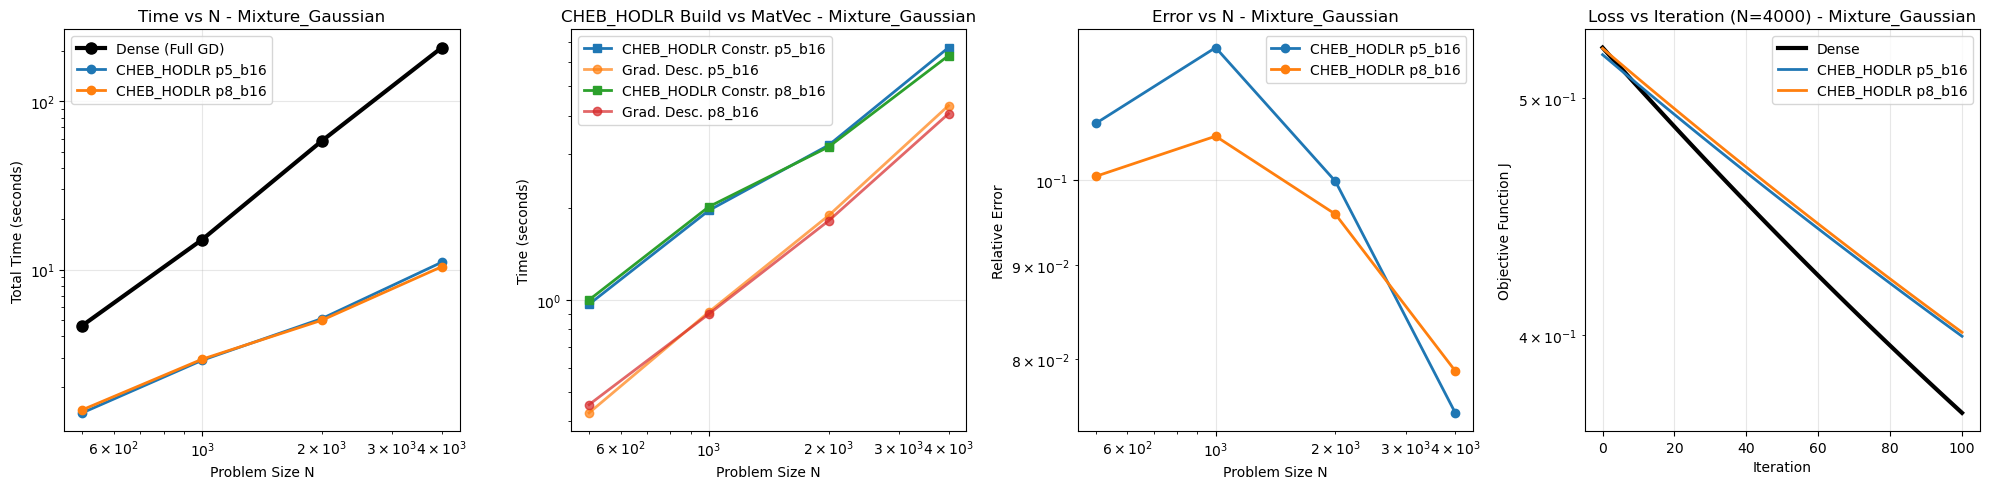

Creating loss vs iteration plot...
Loss vs iteration plot saved as 'loss_vs_iteration_analysis.png'


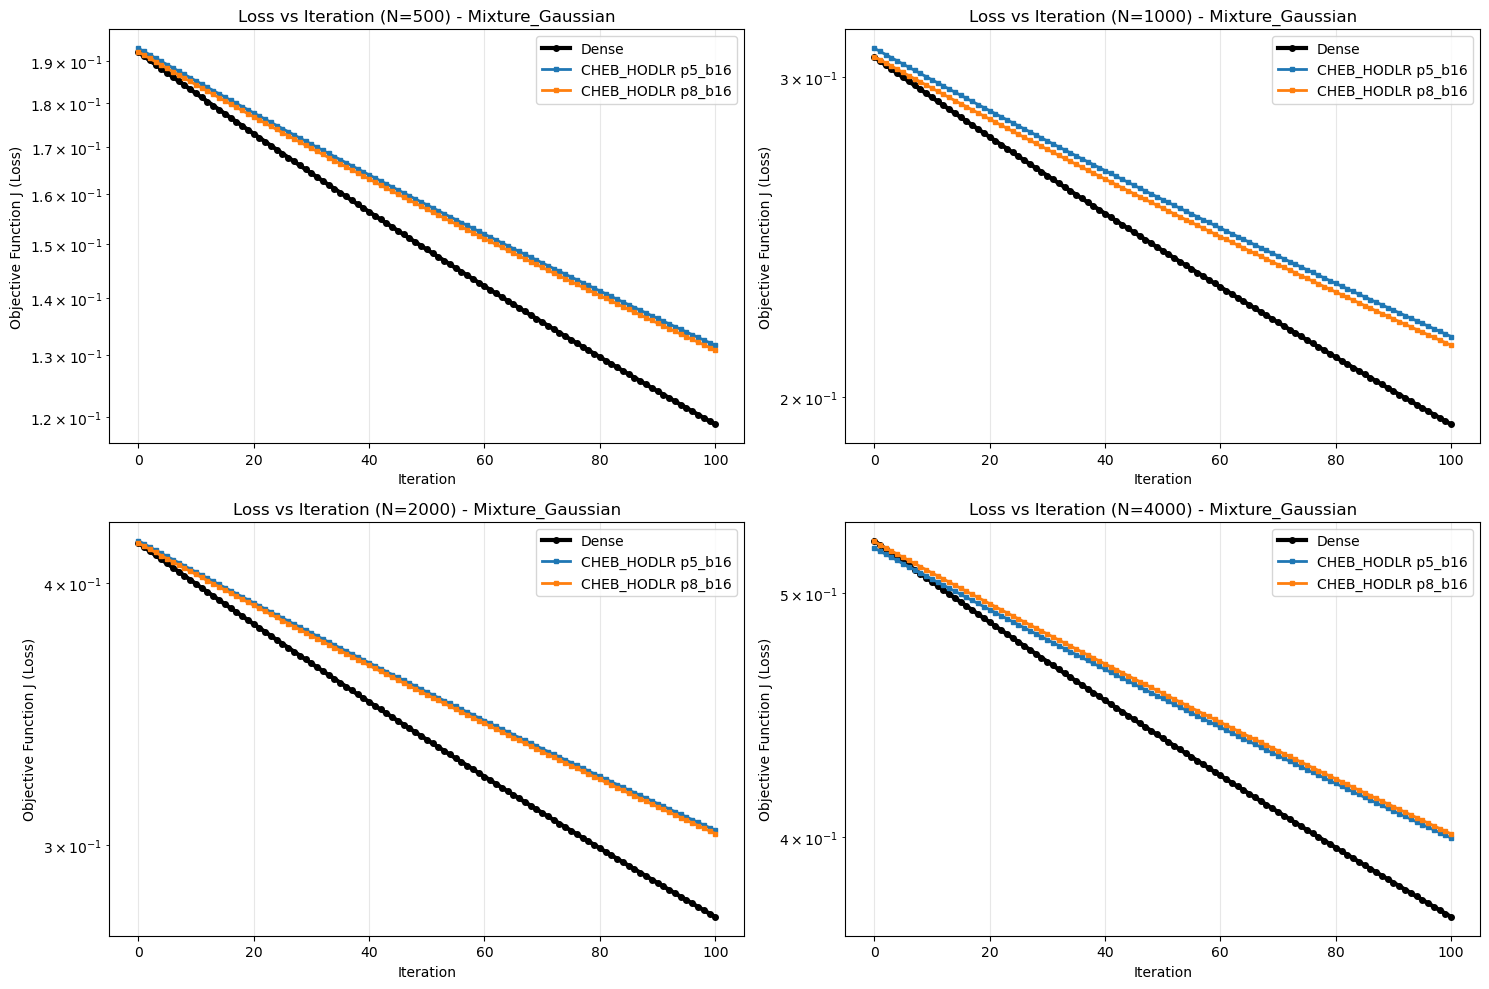

Creating pure gradient descent time plot...
Pure gradient descent time plot saved as 'pure_gradient_descent_time.png'


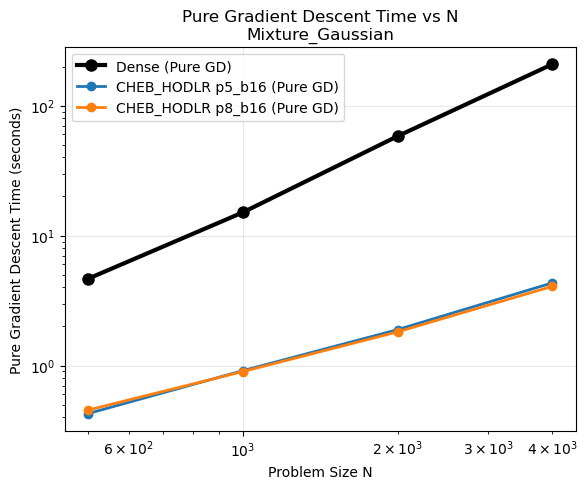

Creating final distributions comparison...
Final distributions plot saved as 'final_distributions_analysis.png'


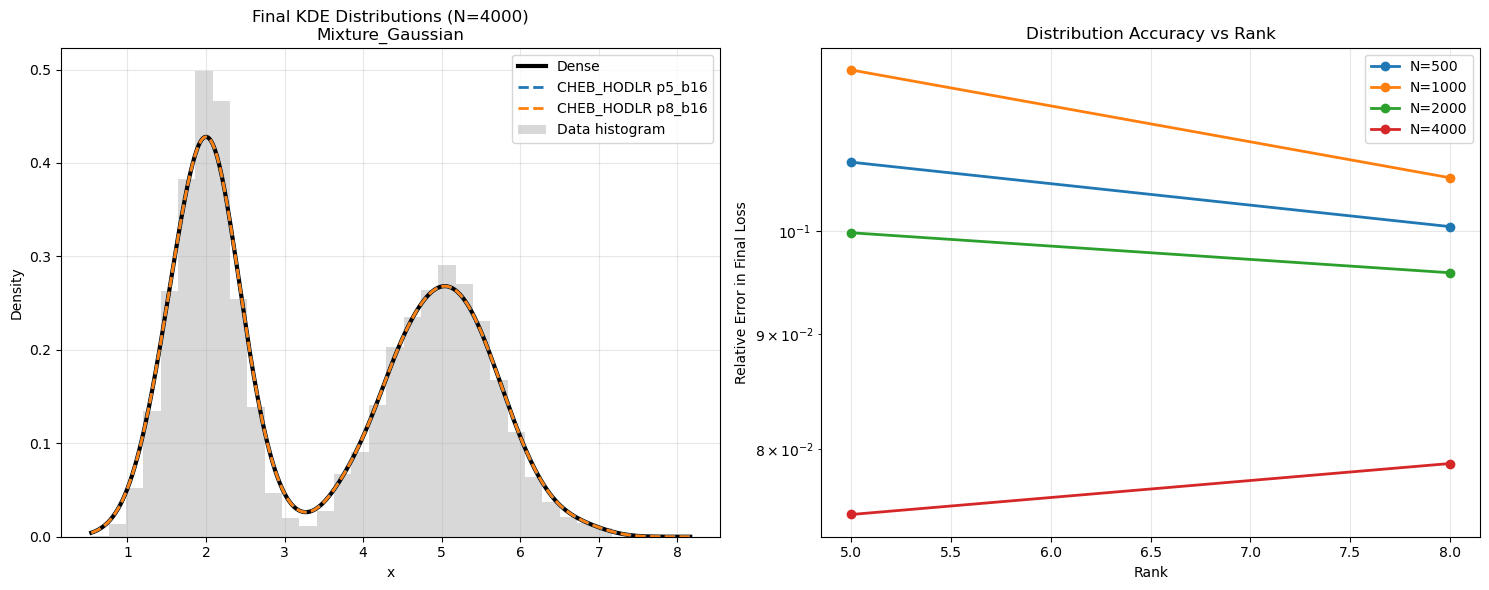

DETAILED TIMING BREAKDOWN: CHEB_HODLR Build vs MatVec

MIXTURE_GAUSSIAN Distribution:
N        Method          Total    CHEB_HODLR_Constr Grad_Desc  Constr_Ratio Speedup 
500      Dense           4.646    -            4.646      -            1.00x   
500      CHEB_HODLR_p5_b16 1.407    0.967        0.426      0.687        3.30x   
500      CHEB_HODLR_p8_b16 1.466    0.999        0.454      0.681        3.17x   
1000     Dense           15.061   -            15.061     -            1.00x   
1000     CHEB_HODLR_p5_b16 2.889    1.962        0.912      0.679        5.21x   
1000     CHEB_HODLR_p8_b16 2.931    2.017        0.898      0.688        5.14x   
2000     Dense           58.178   -            58.178     -            1.00x   
2000     CHEB_HODLR_p5_b16 5.114    3.210        1.889      0.628        11.38x  
2000     CHEB_HODLR_p8_b16 4.999    3.169        1.815      0.634        11.64x  
4000     Dense           208.375  -            208.375    -            1.00x   
4000     CHEB_HOD

In [284]:
results, N_values = run_quick_demo()

Starting comprehensive CHEB_HODLR analysis...
This will take several minutes to complete.
COMPREHENSIVE CHEBYSHEV-HODLR vs DENSE ANALYSIS

Analyzing MIXTURE_GAUSSIAN Distribution
  N = 500
Running Dense baseline...
    Running CHEB_HODLR (p=10, min_block=16)...
    Running CHEB_HODLR (p=10, min_block=32)...
    Running CHEB_HODLR (p=15, min_block=16)...
    Running CHEB_HODLR (p=15, min_block=32)...
    Running CHEB_HODLR (p=20, min_block=16)...
    Running CHEB_HODLR (p=20, min_block=32)...
  N = 1000
Running Dense baseline...
    Running CHEB_HODLR (p=10, min_block=16)...
    Running CHEB_HODLR (p=10, min_block=32)...
    Running CHEB_HODLR (p=15, min_block=16)...
    Running CHEB_HODLR (p=15, min_block=32)...
    Running CHEB_HODLR (p=20, min_block=16)...
    Running CHEB_HODLR (p=20, min_block=32)...
  N = 2000
Running Dense baseline...
    Running CHEB_HODLR (p=10, min_block=16)...
    Running CHEB_HODLR (p=10, min_block=32)...
    Running CHEB_HODLR (p=15, min_block=16)...
    Ru

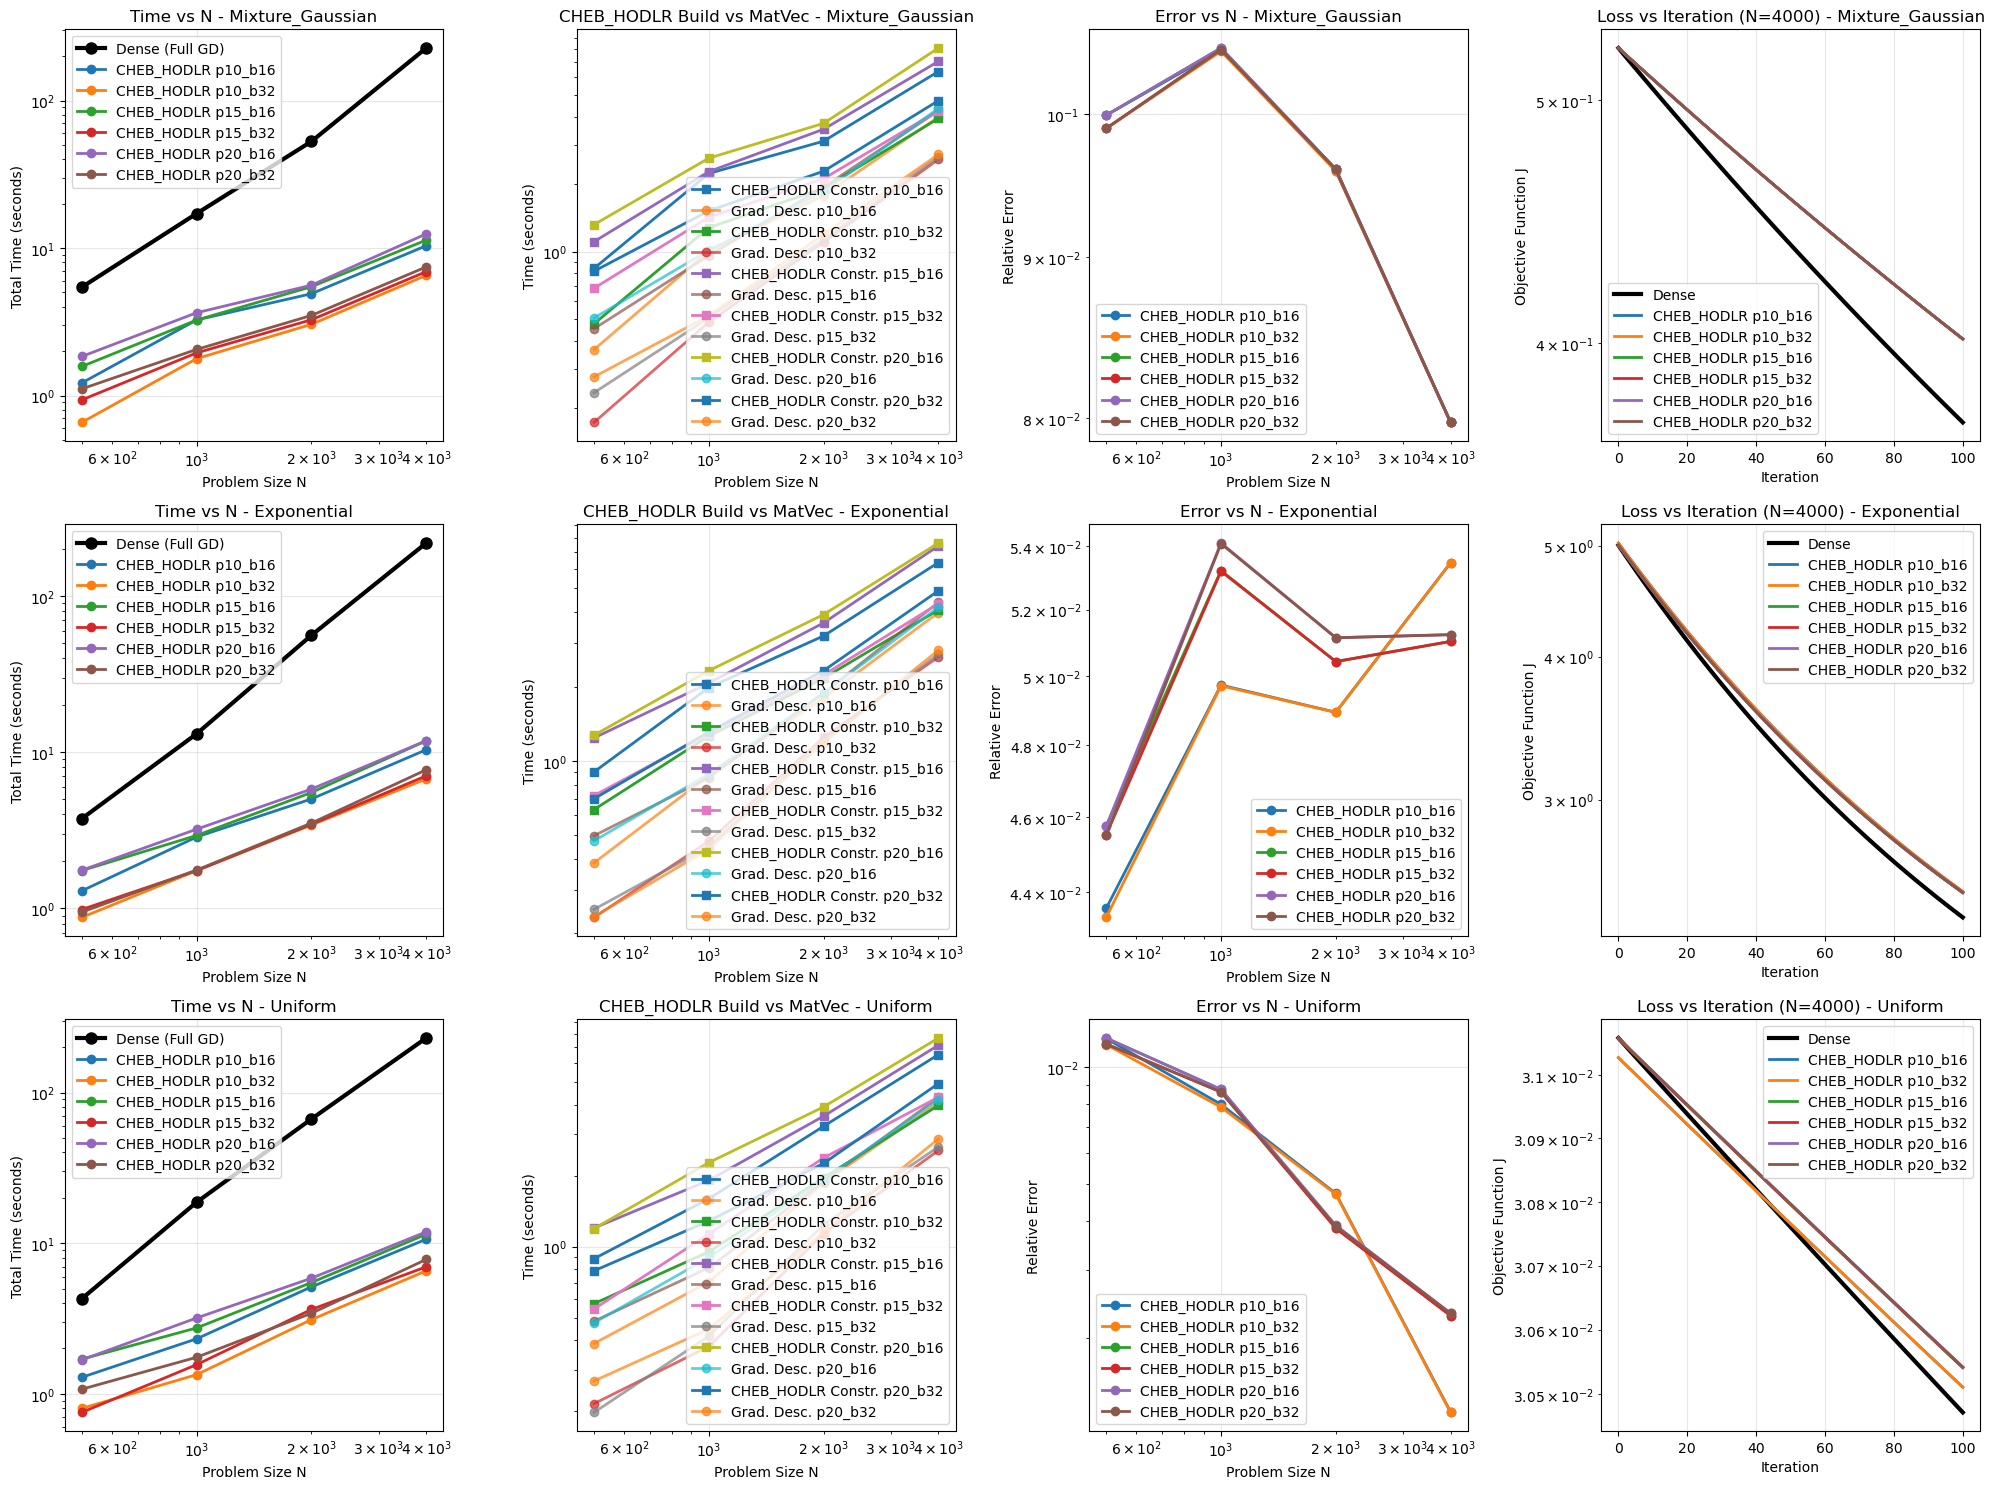

Loss vs iteration plot saved as 'loss_vs_iteration_analysis.png'


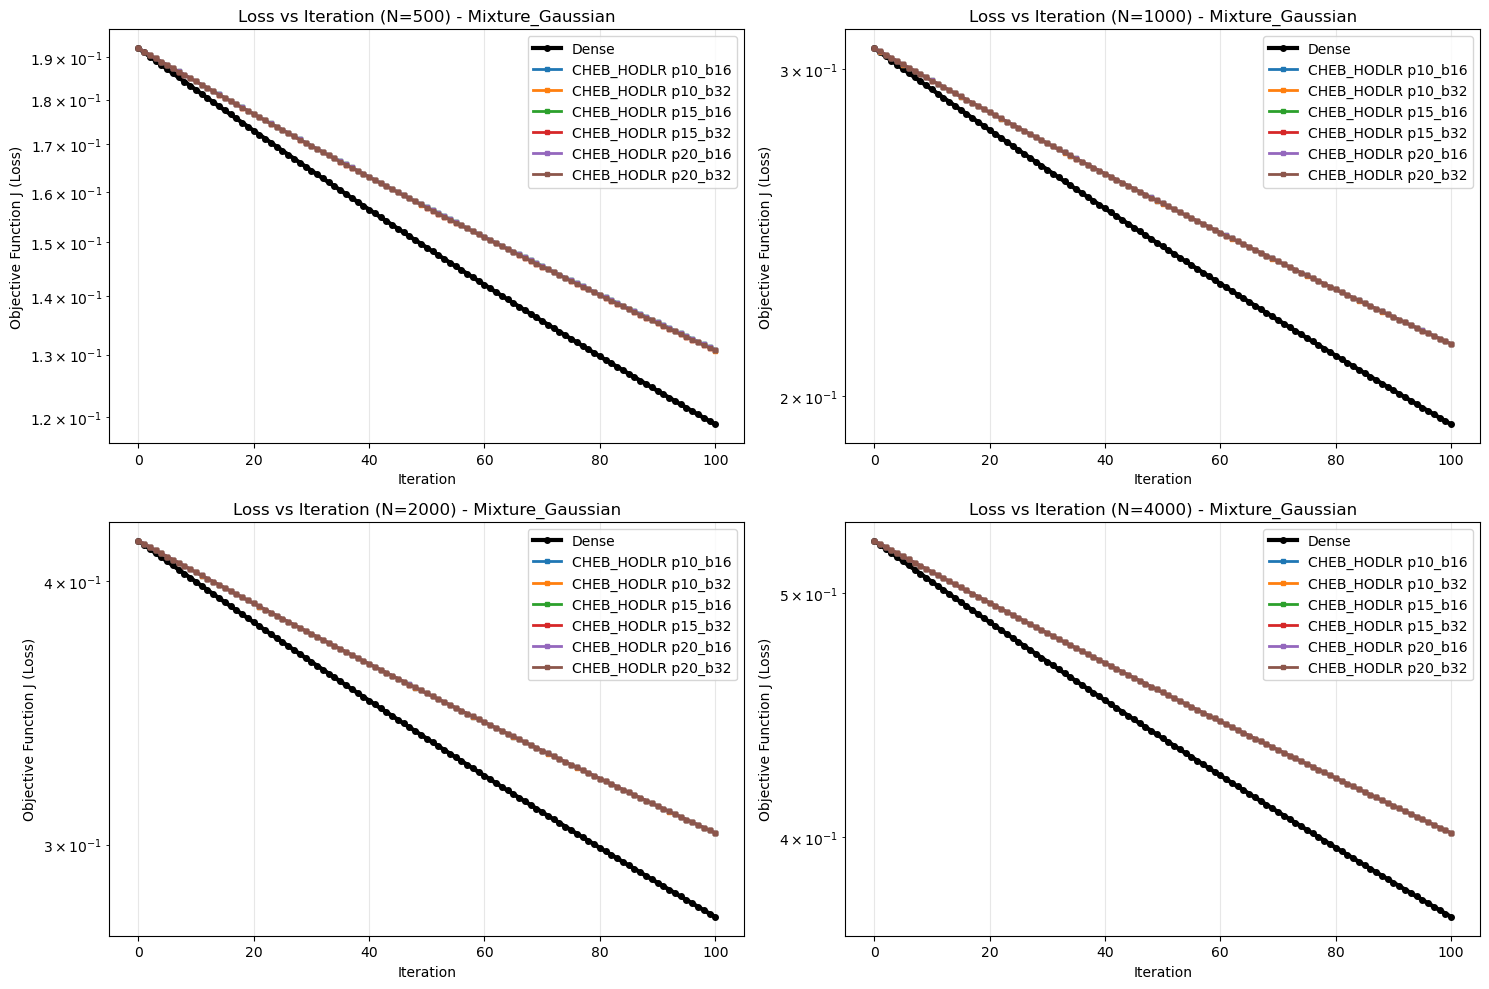

Loss vs iteration plot saved as 'loss_vs_iteration_analysis.png'


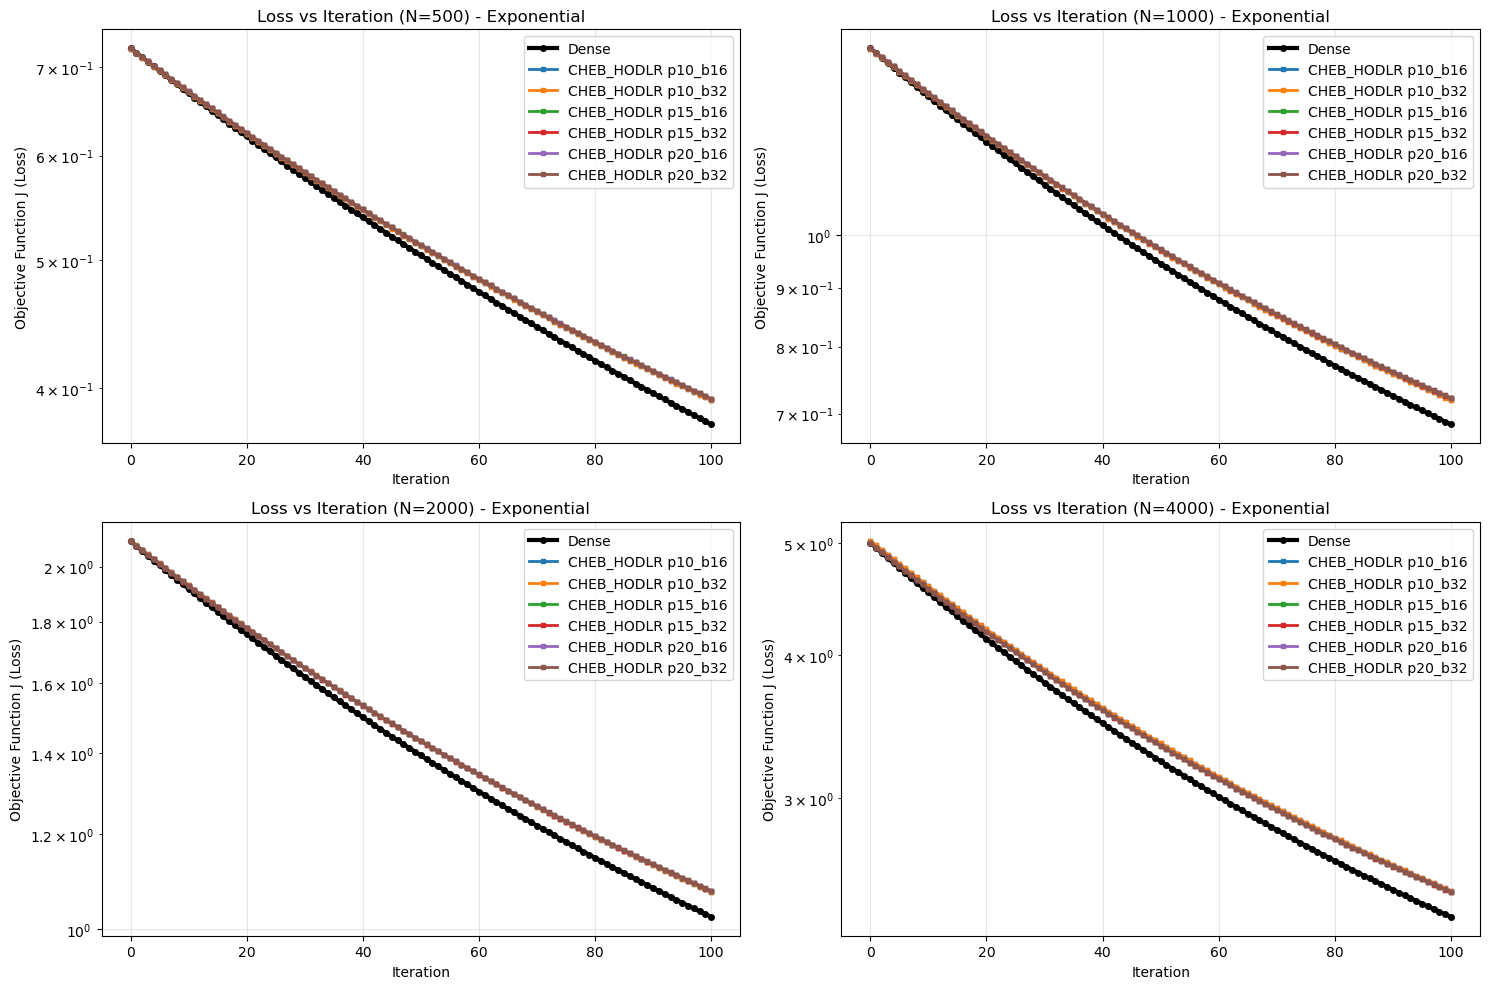

Loss vs iteration plot saved as 'loss_vs_iteration_analysis.png'


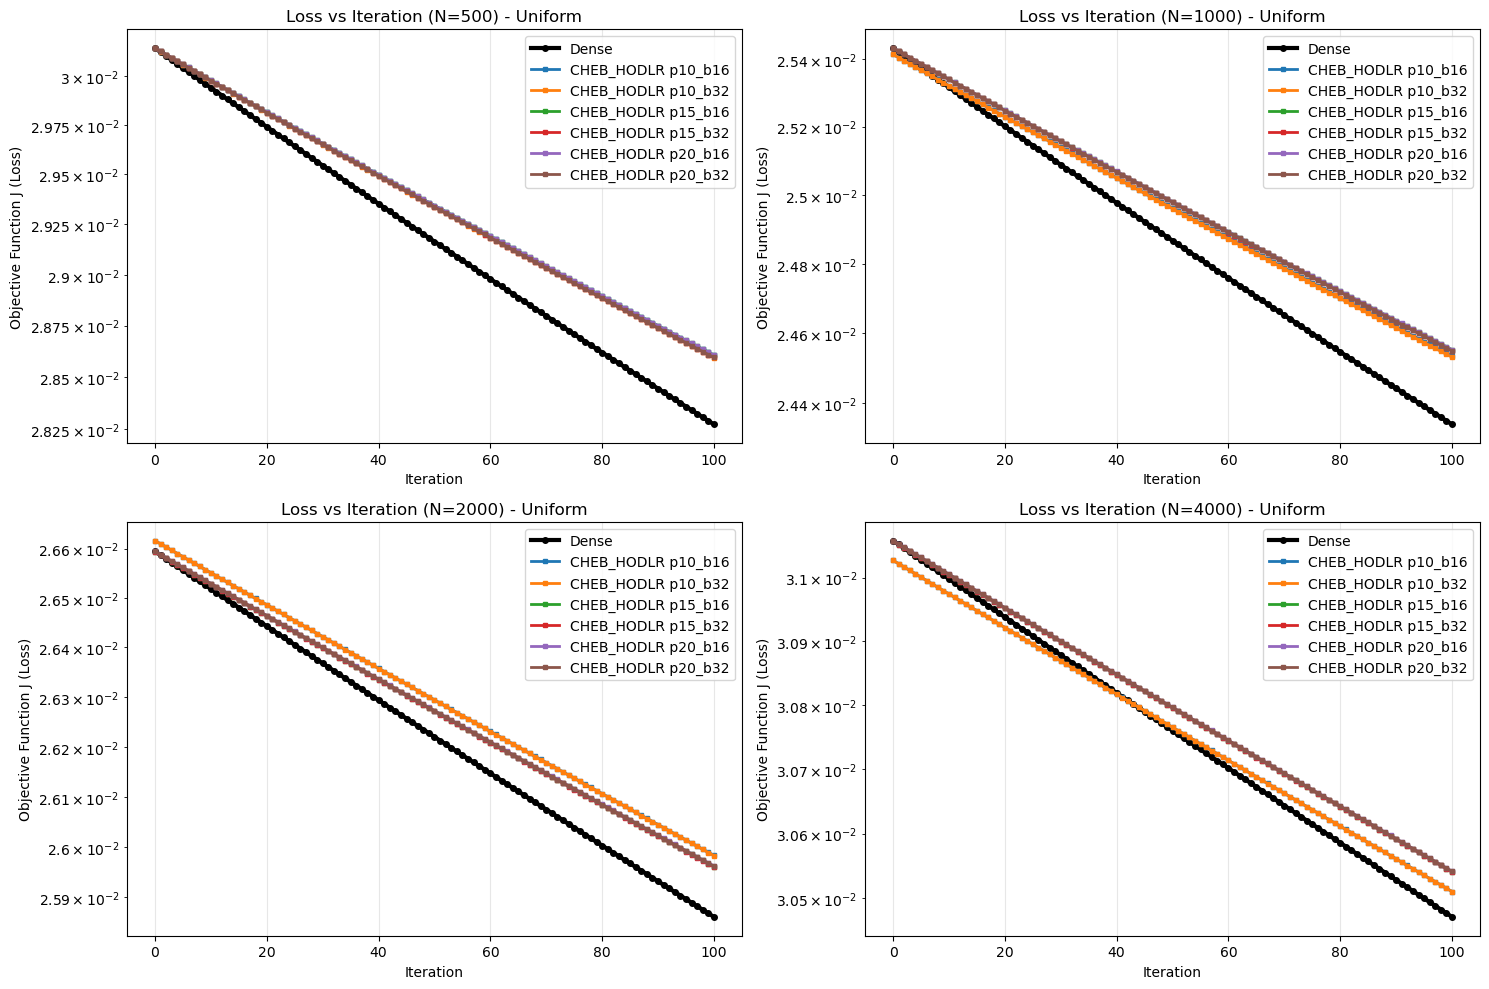

Pure gradient descent time plot saved as 'pure_gradient_descent_time.png'


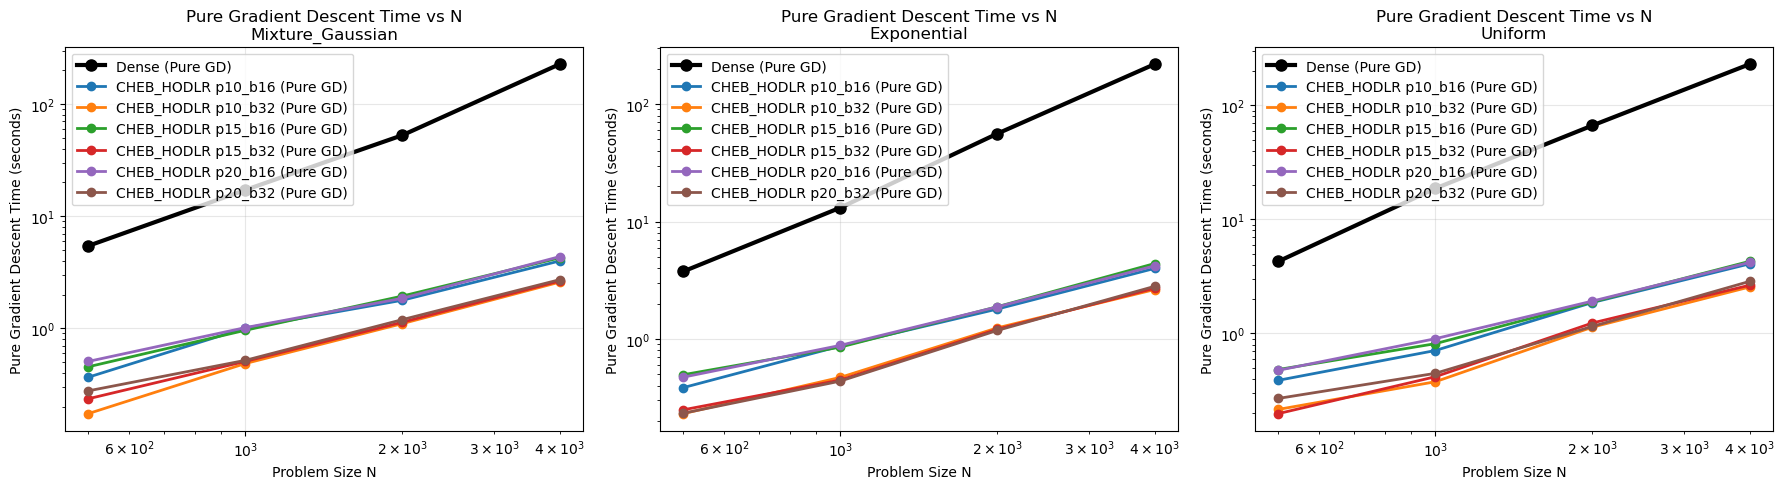

Final distributions plot saved as 'final_distributions_analysis.png'


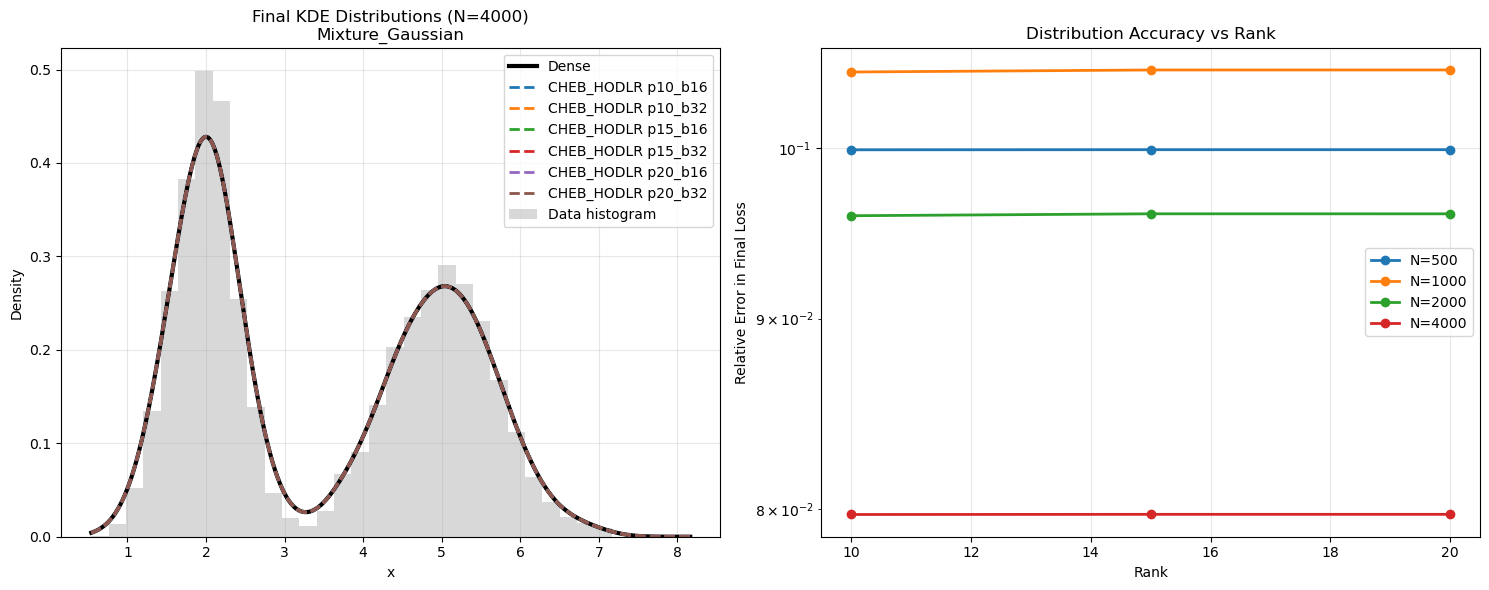

Final distributions plot saved as 'final_distributions_analysis.png'


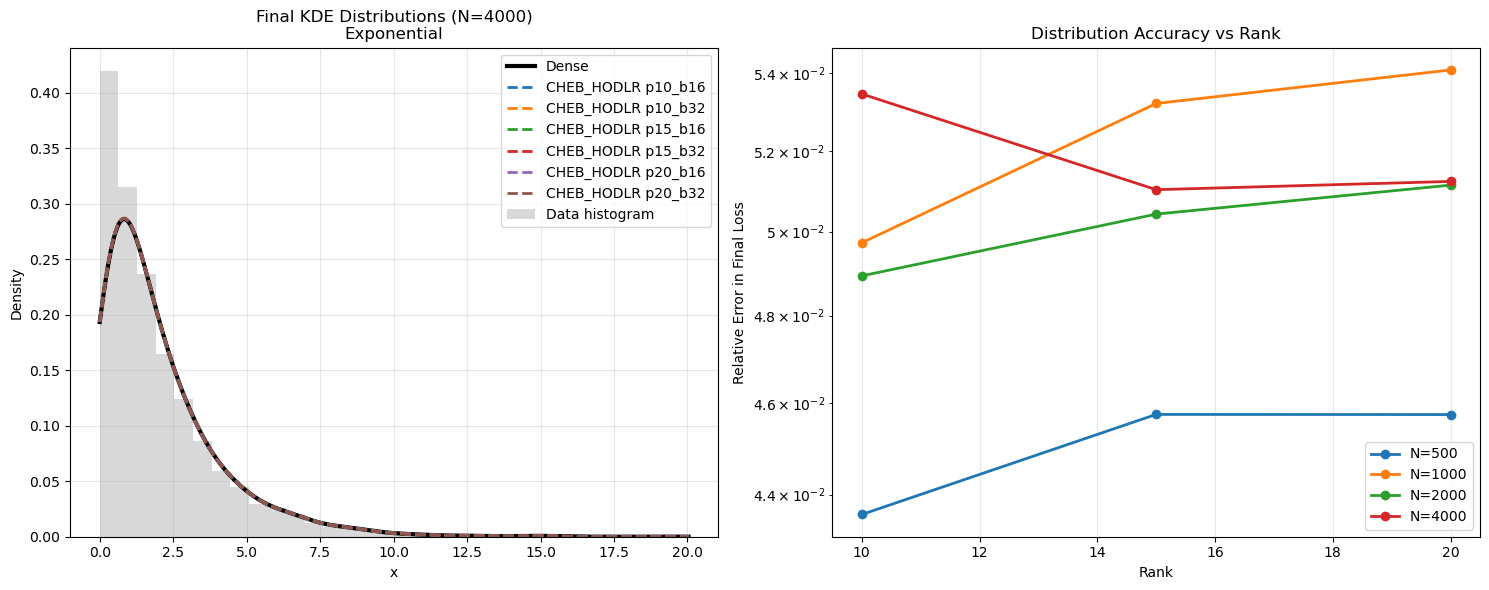

Final distributions plot saved as 'final_distributions_analysis.png'


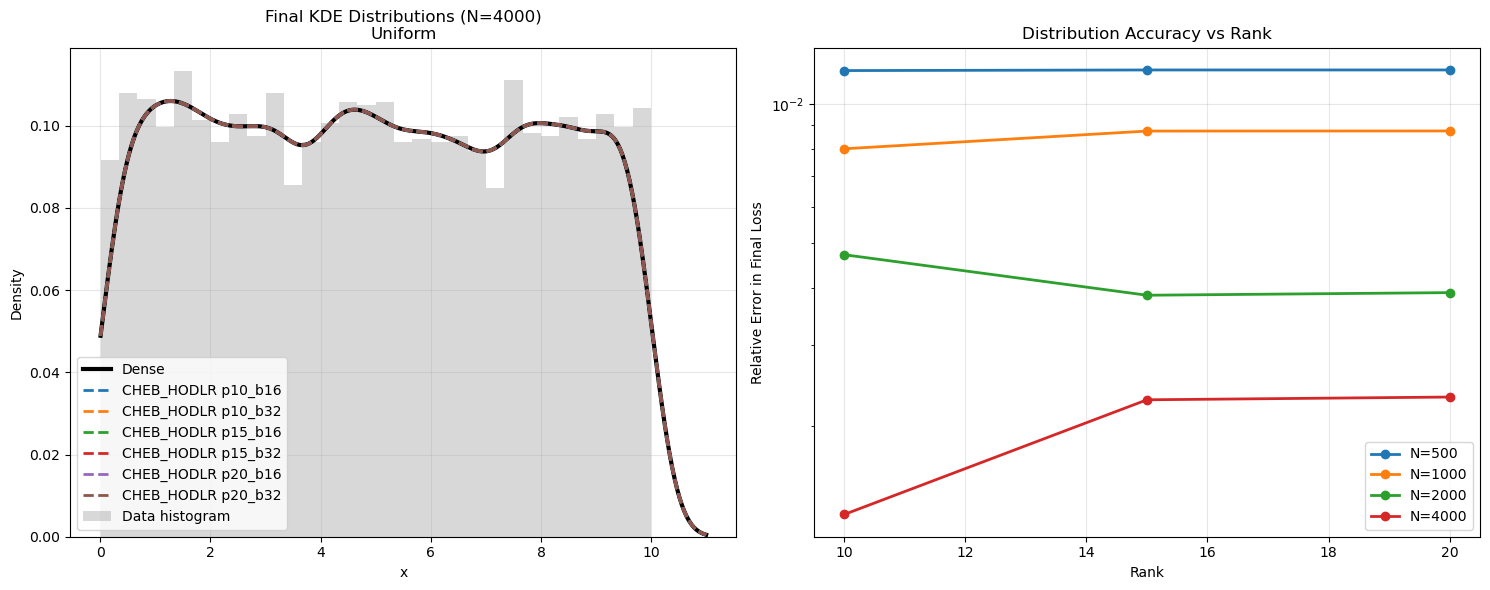

Rank analysis plot saved as 'hodlr_rank_analysis.png'


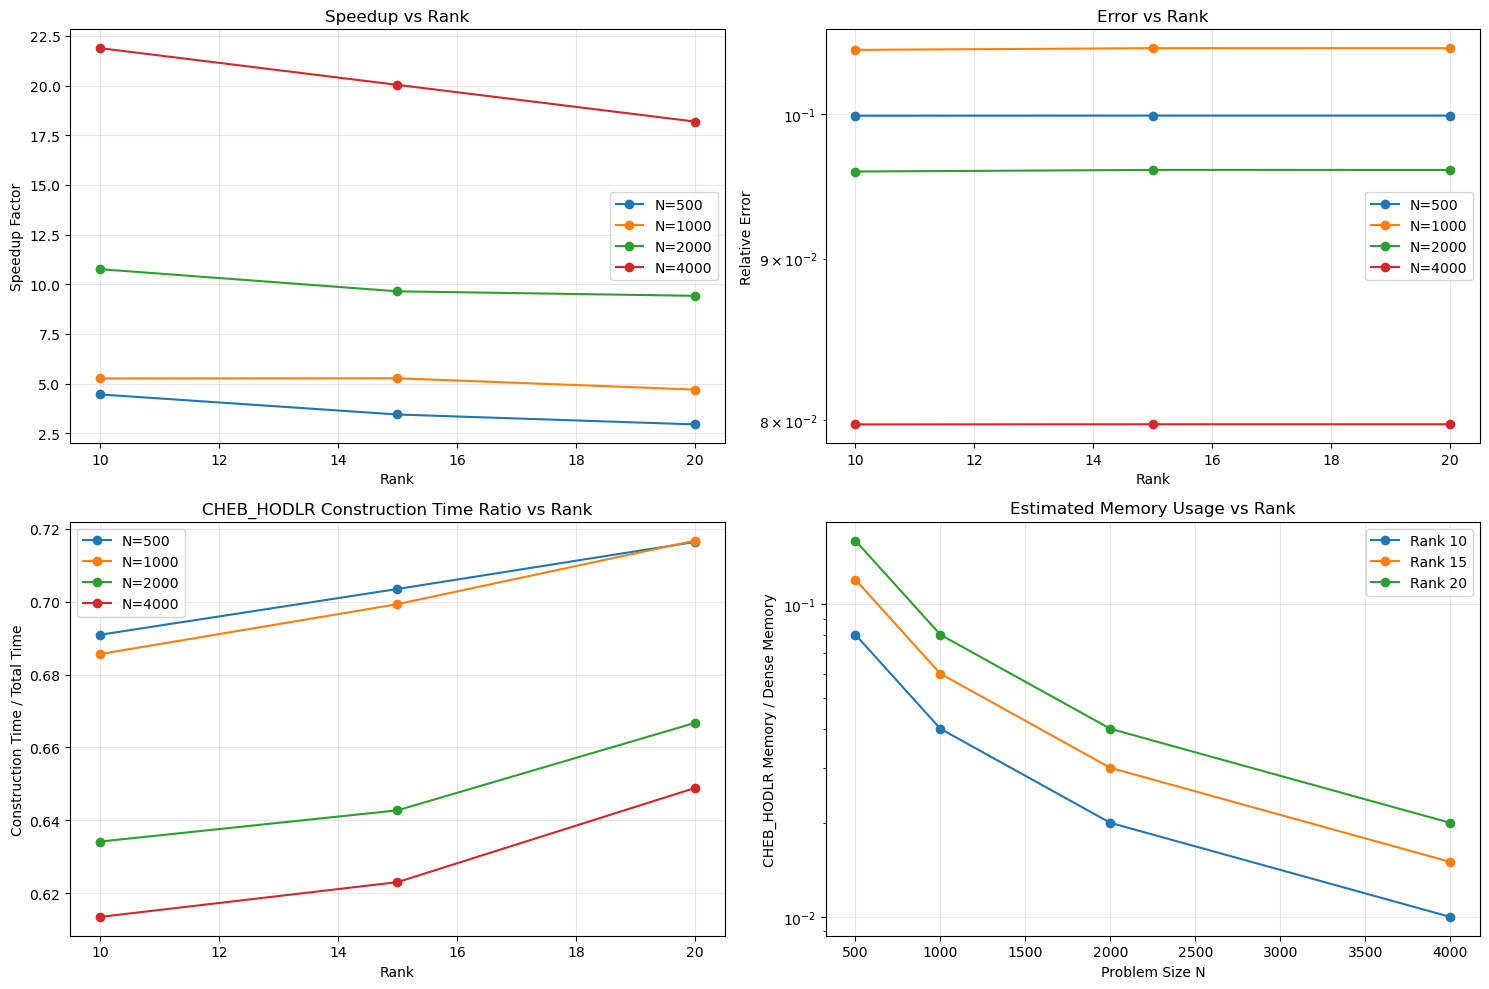

DETAILED TIMING BREAKDOWN: CHEB_HODLR Build vs MatVec

MIXTURE_GAUSSIAN Distribution:
N        Method          Total    CHEB_HODLR_Constr Grad_Desc  Constr_Ratio Speedup 
500      Dense           5.432    -            5.432      -            1.00x   
500      CHEB_HODLR_p10_b16 1.219    0.842        0.366      0.691        4.46x   
500      CHEB_HODLR_p10_b32 0.658    0.477        0.173      0.724        8.25x   
500      CHEB_HODLR_p15_b16 1.576    1.109        0.454      0.703        3.45x   
500      CHEB_HODLR_p15_b32 0.935    0.687        0.235      0.735        5.81x   
500      CHEB_HODLR_p20_b16 1.843    1.320        0.506      0.716        2.95x   
500      CHEB_HODLR_p20_b32 1.111    0.818        0.277      0.736        4.89x   
1000     Dense           17.139   -            17.139     -            1.00x   
1000     CHEB_HODLR_p10_b16 3.256    2.233        1.005      0.686        5.26x   
1000     CHEB_HODLR_p10_b32 1.781    1.279        0.485      0.718        9.62x   
1000 

In [285]:
results, N_values = run_complete_analysis()

In [286]:
import time

N_test_cheb  = [1000, 2000, 4000, 8000, 16000]
N_test_dense = [1000, 2000, 4000, 8000, 16000]   # Dense is too slow at 8000

times_cheb  = []
times_dense = []

# Dense timing (small N only)
for N in N_test_dense:
    x = generate_mixture_gaussian_data(N)
    z = 0.5*(x[:-1]+x[1:])
    h = np.full(N, 0.3)
    print(f"Dense N={N}...", flush=True)
    t0 = time.perf_counter()
    for _ in range(3):
        y = K((z[:,None]-x[None,:])/h[None,:]) @ np.ones(N) / N
    times_dense.append((time.perf_counter()-t0)/3)
    print(f"  done: {times_dense[-1]:.4f}s", flush=True)

# Cheb matvec timing
for N in N_test_cheb:
    x = generate_mixture_gaussian_data(N)
    z = 0.5*(x[:-1]+x[1:])
    h = np.full(N, 0.3)
    print(f"Cheb  N={N}...", flush=True)
    tree = hodlr_build_UV(z, x, p=8, min_block=16)
    hodlr_fill_S_K(tree, z, x, h)
    for _ in range(5):                          # warmup
        y = hodlr_matvec(tree, np.ones(N)) / N
    t0 = time.perf_counter()
    for _ in range(50):                         # timed
        y = hodlr_matvec(tree, np.ones(N)) / N
    times_cheb.append((time.perf_counter()-t0)/50)
    print(f"  done: {times_cheb[-1]:.4f}s", flush=True)

print()
print("Dense")
print(f"{'N':>6} | {'time':>10} | {'ratio':>7}")
for i in range(len(N_test_dense)):
    r = f"{times_dense[i]/times_dense[i-1]:.2f}x" if i>0 else "  -  "
    print(f"{N_test_dense[i]:>6} | {times_dense[i]:>10.4f}s | {r:>7}")

print()
print("Cheb matvec")
print(f"{'N':>6} | {'time':>10} | {'ratio':>7}")
for i in range(len(N_test_cheb)):
    r = f"{times_cheb[i]/times_cheb[i-1]:.2f}x" if i>0 else "  -  "
    print(f"{N_test_cheb[i]:>6} | {times_cheb[i]:>10.4f}s | {r:>7}")

print("\nDense ~4x per doubling = O(N²)")
print("Cheb  ~2x per doubling = O(N log N)")

Dense N=1000...
  done: 0.0505s
Dense N=2000...
  done: 0.2117s
Dense N=4000...
  done: 0.8942s
Dense N=8000...
  done: 3.1153s
Dense N=16000...
  done: 14.7713s
Cheb  N=1000...
  done: 0.0026s
Cheb  N=2000...
  done: 0.0070s
Cheb  N=4000...
  done: 0.0144s
Cheb  N=8000...
  done: 0.0280s
Cheb  N=16000...
  done: 0.0536s

Dense
     N |       time |   ratio
  1000 |     0.0505s |     -  
  2000 |     0.2117s |   4.19x
  4000 |     0.8942s |   4.22x
  8000 |     3.1153s |   3.48x
 16000 |    14.7713s |   4.74x

Cheb matvec
     N |       time |   ratio
  1000 |     0.0026s |     -  
  2000 |     0.0070s |   2.70x
  4000 |     0.0144s |   2.07x
  8000 |     0.0280s |   1.94x
 16000 |     0.0536s |   1.92x

Dense ~4x per doubling = O(N²)
Cheb  ~2x per doubling = O(N log N)
